In [29]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches
from PIL import Image
from scipy import ndimage as ndi
from skimage import color, feature, filters, measure, morphology, segmentation

plt.rcParams["figure.figsize"] = (10, 7)
plt.rcParams["axes.titlesize"] = 14

image_path = Path("BloodSmear.jpg")
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

overlay_path = output_dir / "sickle_cell_candidates.png"
table_path = output_dir / "erythrocyte_measurements.csv"

image_rgb = np.array(Image.open(image_path).convert("RGB"))
image_gray = color.rgb2gray(image_rgb)
image_hsv = color.rgb2hsv(image_rgb)
image_saturation = image_hsv[..., 1]
image_value = image_hsv[..., 2]

print(f"Image: {image_path}")
print(f"Shape: {image_rgb.shape}")
print(f"Overlay output: {overlay_path}")
print(f"Table output: {table_path}")

Image: BloodSmear.jpg
Shape: (767, 960, 3)
Overlay output: outputs\sickle_cell_candidates.png
Table output: outputs\erythrocyte_measurements.csv


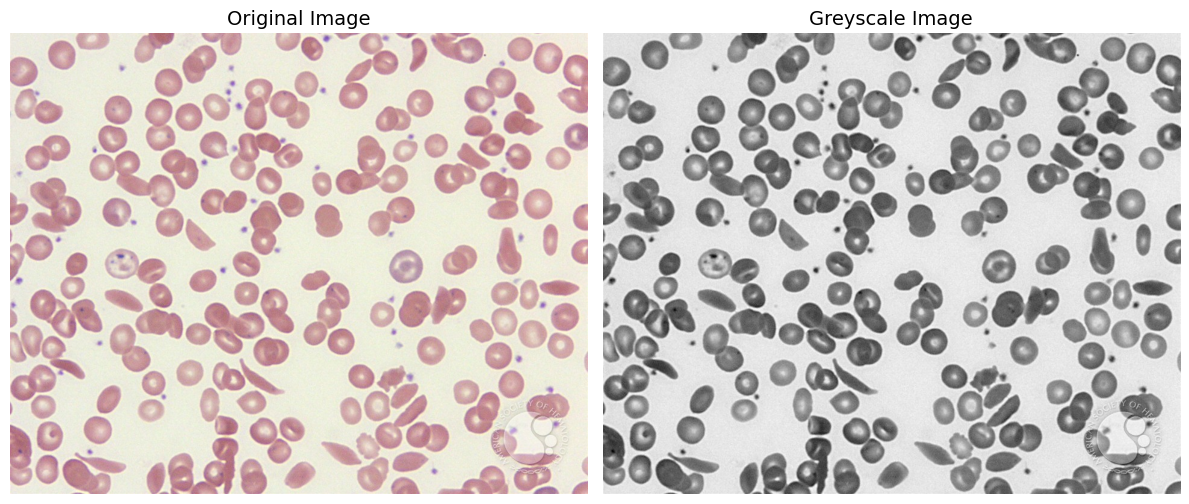

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(image_gray, cmap="gray")
axes[1].set_title("Greyscale Image")
axes[1].axis("off")

plt.tight_layout()

In [31]:
# Build a color-aware mask. Saturation highlights stained cell rims better than grayscale,
# and filling enclosed regions reduces false splits caused by pale centers.
saturation_smooth = filters.gaussian(image_saturation, sigma=1.0)
value_smooth = filters.gaussian(image_value, sigma=1.0)
gray_smooth = filters.gaussian(image_gray, sigma=0.8)

saturation_threshold = filters.threshold_otsu(saturation_smooth)
gray_threshold = filters.threshold_otsu(gray_smooth)

rim_mask = saturation_smooth > (saturation_threshold * 0.92)
interior_mask = gray_smooth < (gray_threshold * 0.99)
cell_mask = rim_mask | interior_mask
cell_mask = morphology.binary_closing(cell_mask, morphology.disk(2))
cell_mask = ndi.binary_fill_holes(cell_mask)
cell_mask = morphology.binary_opening(cell_mask, morphology.disk(1))
cell_mask = morphology.remove_small_objects(cell_mask, min_size=90)
cell_mask = morphology.remove_small_holes(cell_mask, area_threshold=220)

# Estimate a typical single-cell area from connected components so elongated but still
# single erythrocytes are less likely to receive multiple watershed seeds.
component_labels = measure.label(cell_mask)
single_cell_components = [
    region.area
    for region in measure.regionprops(component_labels)
    if 120 <= region.area <= 1200
]
single_cell_area = float(np.median(single_cell_components)) if single_cell_components else 600.0

# Build markers from the filled cell mask, then run marker-controlled watershed on a boundary
# map. The boundary map relies more on cell edges than center color, so central pallor is less
# likely to create incorrect internal splits.
distance_map = ndi.distance_transform_edt(cell_mask)
distance_smooth = filters.gaussian(distance_map, sigma=1.0)
peak_coords = feature.peak_local_max(
    distance_smooth,
    labels=cell_mask,
    min_distance=6,
    threshold_rel=0.12,
    exclude_border=False,
)

marker_mask = np.zeros_like(cell_mask, dtype=bool)
for region in measure.regionprops(component_labels):
    if region.area < 120:
        continue

    component_peak_coords = peak_coords[
        component_labels[peak_coords[:, 0], peak_coords[:, 1]] == region.label
    ] if len(peak_coords) else np.empty((0, 2), dtype=int)
    aspect_ratio = region.major_axis_length / max(region.minor_axis_length, 1e-6)
    circularity = (4 * np.pi * region.area) / max(region.perimeter ** 2, 1e-6)
    expected_markers = max(1, int(np.ceil(region.area / (single_cell_area * 0.95))))

    if region.area < single_cell_area * 1.30 and aspect_ratio <= 2.1 and circularity >= 0.76:
        expected_markers = 1

    if len(component_peak_coords) == 0:
        component_pixels = np.argwhere(component_labels == region.label)
        component_values = distance_smooth[component_labels == region.label]
        marker_mask[tuple(component_pixels[np.argmax(component_values)])] = True
        continue

    peak_values = distance_smooth[component_peak_coords[:, 0], component_peak_coords[:, 1]]
    dominant_peak = float(np.max(peak_values))
    strong_peak_mask = peak_values >= (dominant_peak * 0.65)
    component_peak_coords = component_peak_coords[strong_peak_mask]
    peak_values = peak_values[strong_peak_mask]

    if len(component_peak_coords) == 0:
        component_pixels = np.argwhere(component_labels == region.label)
        component_values = distance_smooth[component_labels == region.label]
        marker_mask[tuple(component_pixels[np.argmax(component_values)])] = True
        continue

    keep_indices = np.argsort(peak_values)[-expected_markers:]
    marker_mask[tuple(component_peak_coords[keep_indices].T)] = True

markers, _ = ndi.label(marker_mask)

edge_map = (
    0.55 * filters.sobel(saturation_smooth)
    + 0.25 * filters.sobel(value_smooth)
    + 0.20 * filters.sobel(gray_smooth)
)
distance_norm = distance_smooth / max(float(distance_smooth.max()), 1e-6)
watershed_surface = filters.gaussian(edge_map - (0.35 * distance_norm), sigma=0.8)
labeled_cells = segmentation.watershed(watershed_surface, markers, mask=cell_mask)

print(f"Saturation threshold: {saturation_threshold:.4f}")
print(f"Greyscale threshold: {gray_threshold:.4f}")
print(f"Estimated single-cell area: {single_cell_area:.1f} pixels")
print(f"Watershed markers used: {markers.max()}")
print(f"Detected watershed regions: {labeled_cells.max()}")

Saturation threshold: 0.1681
Greyscale threshold: 0.7731
Estimated single-cell area: 671.0 pixels
Watershed markers used: 178
Detected watershed regions: 178


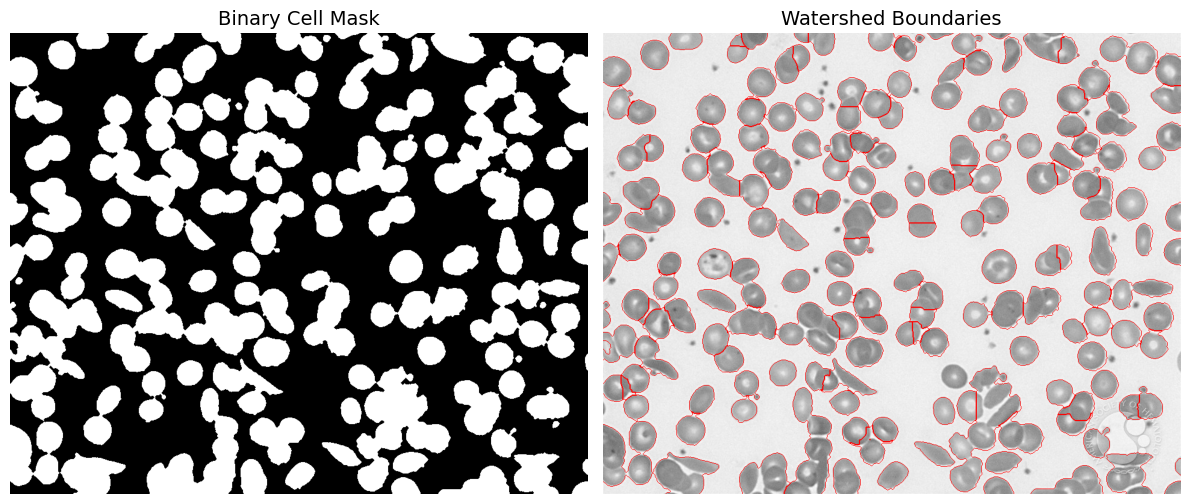

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cell_mask, cmap="gray")
axes[0].set_title("Binary Cell Mask")
axes[0].axis("off")

axes[1].imshow(segmentation.mark_boundaries(image_gray, labeled_cells, color=(1, 0, 0)))
axes[1].set_title("Watershed Boundaries")
axes[1].axis("off")

plt.tight_layout()

In [33]:
records = []

for region in measure.regionprops(labeled_cells):
    if region.area < 120 or region.area > 4000:
        continue
    if region.minor_axis_length < 8:
        continue

    min_row, min_col, max_row, max_col = region.bbox
    major_axis = float(region.major_axis_length)
    minor_axis = float(region.minor_axis_length)
    aspect_ratio = major_axis / max(minor_axis, 1e-6)
    axis_difference = major_axis - minor_axis
    eccentricity = float(region.eccentricity)
    solidity = float(region.solidity)
    touches_border = (
        min_row == 0
        or min_col == 0
        or max_row == labeled_cells.shape[0]
        or max_col == labeled_cells.shape[1]
    )

    likely_split_fragment = (
        region.area < single_cell_area * 0.45
        and aspect_ratio >= 2.2
        and solidity >= 0.93
    )
    sickle_candidate = (not likely_split_fragment) and (
        (aspect_ratio >= 2.2 and region.area >= single_cell_area * 0.45)
        or (aspect_ratio >= 1.9 and eccentricity >= 0.84 and axis_difference >= 14 and region.area >= single_cell_area * 0.45)
        or (aspect_ratio >= 1.7 and eccentricity >= 0.88 and solidity <= 0.90 and axis_difference >= 12 and region.area >= single_cell_area * 0.50)
    )

    records.append(
        {
            "label": int(region.label),
            "area": float(region.area),
            "centroid_row": float(region.centroid[0]),
            "centroid_col": float(region.centroid[1]),
            "major_axis_length": major_axis,
            "minor_axis_length": minor_axis,
            "axis_difference": axis_difference,
            "aspect_ratio": aspect_ratio,
            "eccentricity": eccentricity,
            "solidity": solidity,
            "touches_border": bool(touches_border),
            "sickle_candidate": bool(sickle_candidate),
            "min_row": int(min_row),
            "min_col": int(min_col),
            "max_row": int(max_row),
            "max_col": int(max_col),
        }
    )

features = pd.DataFrame(records).sort_values(["sickle_candidate", "aspect_ratio"], ascending=[False, False]).reset_index(drop=True)

print(f"Usable erythrocytes measured: {len(features)}")
print(f"Sickle-cell candidates: {int(features['sickle_candidate'].sum())}")
print(f"Candidates touching image border: {int((features['sickle_candidate'] & features['touches_border']).sum())}")

features.head(12)

Usable erythrocytes measured: 170
Sickle-cell candidates: 19
Candidates touching image border: 4


,label,area,centroid_row,centroid_col,major_axis_length,minor_axis_length,axis_difference,aspect_ratio,eccentricity,solidity,touches_border,sickle_candidate,min_row,min_col,max_row,max_col
0,119,356.0,470.185393,4.289326,46.566859,12.060620,34.506239,3.861067,0.965878,0.822171,True,True,448,0,491,12
1,4,313.0,3.833866,557.348243,41.149971,11.706370,29.443602,3.515178,0.958682,0.915205,True,True,0,538,12,583
2,114,427.0,461.271663,77.412178,53.238962,17.672789,35.566172,3.012482,0.943296,0.539823,False,True,442,59,486,96
3,107,2715.0,430.047514,887.530018,117.604093,39.430376,78.173718,2.982576,0.942118,0.756689,False,True,411,841,460,946
4,86,3126.0,325.937940,285.190339,117.275952,42.707746,74.568207,2.746011,0.931335,0.815762,False,True,292,242,363,341
5,167,1380.0,700.240580,551.912319,68.779999,26.175032,42.604967,2.627695,0.924756,0.950413,False,True,681,518,721,584
6,109,1426.0,445.109397,188.623422,67.704799,26.978373,40.726426,2.509595,0.917181,0.957690,False,True,428,158,465,220
7,94,1085.0,376.455300,10.047005,61.415977,24.791914,36.624063,2.477258,0.914904,0.894477,True,True,351,0,413,29
8,177,2876.0,749.696453,786.375522,107.904354,44.491648,63.412706,2.425272,0.911037,0.829536,True,True,720,711,767,830
9,134,2379.0,540.811265,82.799916,94.034228,39.121355,54.912873,2.403655,0.909349,0.798054,False,True,505,53,576,124


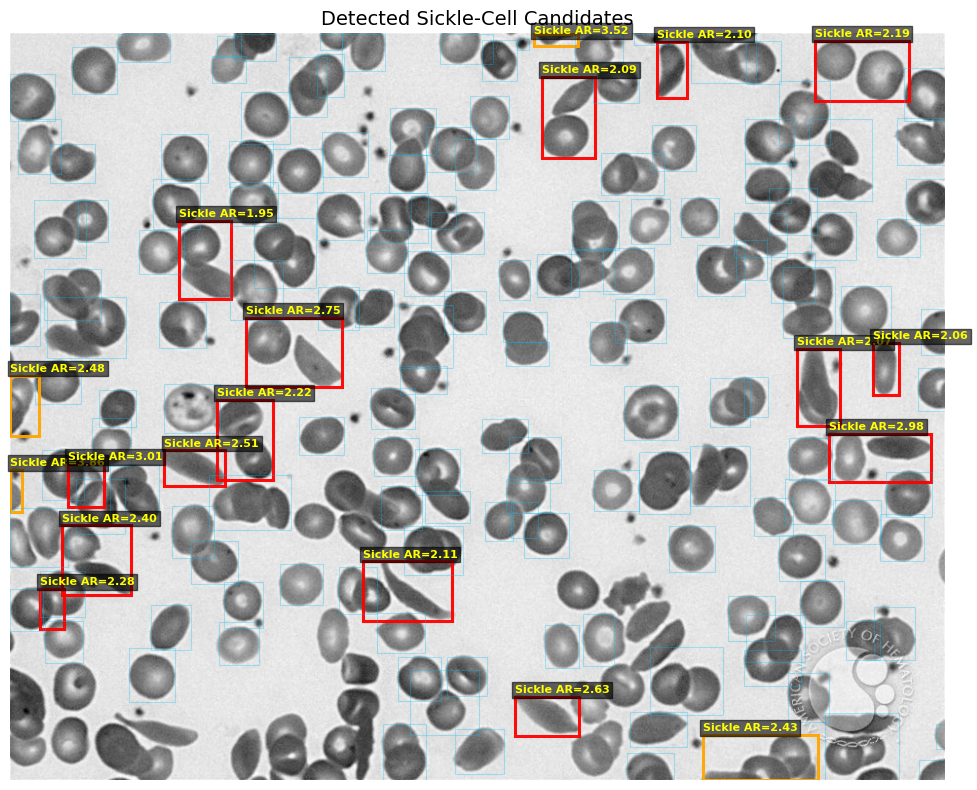

Saved overlay image to: outputs\sickle_cell_candidates.png
Saved measurements table to: outputs\erythrocyte_measurements.csv


In [34]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(image_gray, cmap="gray")
ax.set_title("Detected Sickle-Cell Candidates")
ax.axis("off")

for row in features.itertuples(index=False):
    width = row.max_col - row.min_col
    height = row.max_row - row.min_row

    if row.sickle_candidate:
        edgecolor = "red" if not row.touches_border else "orange"
        linewidth = 2.2
        alpha = 0.95
        label = f"Sickle AR={row.aspect_ratio:.2f}"
    else:
        edgecolor = "deepskyblue"
        linewidth = 0.8
        alpha = 0.30
        label = None

    rect = patches.Rectangle(
        (row.min_col, row.min_row),
        width,
        height,
        linewidth=linewidth,
        edgecolor=edgecolor,
        facecolor="none",
        alpha=alpha,
    )
    ax.add_patch(rect)

    if label is not None:
        ax.text(
            row.min_col,
            max(row.min_row - 4, 0),
            label,
            color="yellow",
            fontsize=8,
            weight="bold",
            bbox={"facecolor": "black", "alpha": 0.60, "pad": 2},
        )

plt.tight_layout()
fig.savefig(overlay_path, dpi=200, bbox_inches="tight")
plt.show()

features.to_csv(table_path, index=False)
print(f"Saved overlay image to: {overlay_path}")
print(f"Saved measurements table to: {table_path}")

In [35]:
summary = features.loc[
    :, [
        "label",
        "major_axis_length",
        "minor_axis_length",
        "axis_difference",
        "aspect_ratio",
        "eccentricity",
        "solidity",
        "touches_border",
        "sickle_candidate",
    ]
]

summary.head(20)

,label,major_axis_length,minor_axis_length,axis_difference,aspect_ratio,eccentricity,solidity,touches_border,sickle_candidate
0,119,46.566859,12.060620,34.506239,3.861067,0.965878,0.822171,True,True
1,4,41.149971,11.706370,29.443602,3.515178,0.958682,0.915205,True,True
2,114,53.238962,17.672789,35.566172,3.012482,0.943296,0.539823,False,True
3,107,117.604093,39.430376,78.173718,2.982576,0.942118,0.756689,False,True
4,86,117.275952,42.707746,74.568207,2.746011,0.931335,0.815762,False,True
5,167,68.779999,26.175032,42.604967,2.627695,0.924756,0.950413,False,True
6,109,67.704799,26.978373,40.726426,2.509595,0.917181,0.957690,False,True
7,94,61.415977,24.791914,36.624063,2.477258,0.914904,0.894477,True,True
8,177,107.904354,44.491648,63.412706,2.425272,0.911037,0.829536,True,True
9,134,94.034228,39.121355,54.912873,2.403655,0.909349,0.798054,False,True
